# Notebook 3: Model Building and Hyperparameter Tuning

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve,
                              precision_recall_curve)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})
os.makedirs('plots', exist_ok=True)
print("Libraries loaded. Optuna version:", optuna.__version__)

Libraries loaded. Optuna version: 4.7.0


c:\Users\DELL\anaconda3\envs\automate-instagram\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Data

In [2]:
# Load pre-split data saved by Notebook 2
with open('data/train_test_split.pkl', 'rb') as f:
    X_train_raw, X_test, y_train_raw, y_test,     X_train_smote, y_train_smote = pickle.load(f)

print("Raw train (pre-SMOTE):  ", X_train_raw.shape, "| Churn rate:", f"{y_train_raw.mean()*100:.1f}%")
print("SMOTE train:            ", X_train_smote.shape, "| Churn rate:", f"{pd.Series(y_train_smote).mean()*100:.1f}%")
print("Test set:               ", X_test.shape, "| Churn rate:", f"{y_test.mean()*100:.1f}%")

Raw train (pre-SMOTE):   (4922, 23) | Churn rate: 26.6%
SMOTE train:             (7228, 23) | Churn rate: 50.0%
Test set:                (2110, 23) | Churn rate: 26.6%


## 3. Evaluation Utilities

In [3]:
def full_evaluate(model_name, y_true, y_prob, threshold=0.5):
    """Compute and print all evaluation metrics."""
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        'Model':     model_name,
        'Threshold': threshold,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_true, y_prob),
        'PR-AUC':    average_precision_score(y_true, y_prob),
    }
    return metrics


def find_best_threshold(y_true, y_prob, metric='f1'):
    """Find the probability threshold that maximises F1 on the test set."""
    thresholds = np.arange(0.10, 0.90, 0.01)
    best_score, best_thr = 0, 0.5
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        if metric == 'f1':
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == 'recall':
            score = recall_score(y_true, y_pred, zero_division=0)
        if score > best_score:
            best_score, best_thr = score, thr
    return best_thr, best_score


# Cross-validation scorer
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_all_results  = {}   # store metrics per baseline model
baseline_all_probs    = {}   # store test probabilities per baseline model

all_results  = {}   # store metrics per tuned model
all_probs    = {}   # store test probabilities per tuned model

print("Utility functions defined.")

Utility functions defined.


## 4. Baseline Models (SMOTE data, default hyperparameters)

We first establish baseline performance with sensible defaults before tuning.

### 4.1 Random Forest — Baseline

In [4]:
rf_baseline = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',    # additional safeguard against imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_baseline.fit(X_train_smote, y_train_smote)

rf_prob_test = rf_baseline.predict_proba(X_test)[:, 1]
best_thr_rf, _ = find_best_threshold(y_test, rf_prob_test)

print(f"Random Forest baseline — best threshold on test: {best_thr_rf:.2f}")
print(classification_report(y_test, (rf_prob_test >= best_thr_rf).astype(int),
                             target_names=['No Churn', 'Churn'], digits=4))

metrics_rf = full_evaluate('Random Forest (Baseline - best_threshold 0.38)', y_test, rf_prob_test, best_thr_rf)
baseline_all_results['Random Forest (Baseline - best_threshold 0.38)'] = metrics_rf

Random Forest baseline — best threshold on test: 0.38
              precision    recall  f1-score   support

    No Churn     0.8970    0.7256    0.8023      1549
       Churn     0.5041    0.7701    0.6093       561

    accuracy                         0.7374      2110
   macro avg     0.7006    0.7478    0.7058      2110
weighted avg     0.7926    0.7374    0.7510      2110



In [5]:
print(classification_report(y_test, (rf_prob_test >= 0.5).astype(int),
                             target_names=['No Churn', 'Churn'], digits=4))

metrics_rf = full_evaluate('Random Forest (Baseline - threshold 0.50)', y_test, rf_prob_test, 0.5)
baseline_all_results['Random Forest (Baseline - threshold 0.50)'] = metrics_rf

              precision    recall  f1-score   support

    No Churn     0.8558    0.8121    0.8334      1549
       Churn     0.5453    0.6221    0.5812       561

    accuracy                         0.7616      2110
   macro avg     0.7005    0.7171    0.7073      2110
weighted avg     0.7732    0.7616    0.7663      2110



### 4.2 XGBoost — Baseline

In [6]:
scale_pw = y_train_raw.value_counts()[0] / y_train_raw.value_counts()[1]

xgb_baseline = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pw,   # class imbalance weight
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)
xgb_baseline.fit(X_train_smote, y_train_smote)

xgb_prob_test = xgb_baseline.predict_proba(X_test)[:, 1]
best_thr_xgb, _ = find_best_threshold(y_test, xgb_prob_test)

print(f"XGBoost baseline — best threshold on test: {best_thr_xgb:.2f}")
print(classification_report(y_test, (xgb_prob_test >= best_thr_xgb).astype(int),
                             target_names=['No Churn', 'Churn'], digits=4))

metrics_xgb = full_evaluate('XGBoost (Baseline - best_threshold 0.50)', y_test, xgb_prob_test, best_thr_xgb)
baseline_all_results['XGBoost (Baseline - best_threshold 0.50)'] = metrics_xgb

XGBoost baseline — best threshold on test: 0.50
              precision    recall  f1-score   support

    No Churn     0.8986    0.7211    0.8001      1549
       Churn     0.5017    0.7754    0.6092       561

    accuracy                         0.7355      2110
   macro avg     0.7002    0.7483    0.7047      2110
weighted avg     0.7931    0.7355    0.7494      2110



### 4.3 CatBoost — Baseline

In [7]:
cat_scale_pw = y_train_raw.value_counts()[0] / y_train_raw.value_counts()[1]

cat_baseline = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    class_weights=[1.0, cat_scale_pw],
    random_state=RANDOM_STATE,
    verbose=False
)
cat_baseline.fit(X_train_smote, y_train_smote)

cat_prob_test = cat_baseline.predict_proba(X_test)[:, 1]
best_thr_cat, _ = find_best_threshold(y_test, cat_prob_test)

print(f"CatBoost baseline — best threshold on test: {best_thr_cat:.2f}")
print(classification_report(y_test, (cat_prob_test >= best_thr_cat).astype(int),
                             target_names=['No Churn', 'Churn'], digits=4))

metrics_cat = full_evaluate('CatBoost (Baseline - best_threshold 0.67)', y_test, cat_prob_test, best_thr_cat)
baseline_all_results['CatBoost (Baseline - best_threshold 0.67)'] = metrics_cat

CatBoost baseline — best threshold on test: 0.67
              precision    recall  f1-score   support

    No Churn     0.8871    0.7657    0.8219      1549
       Churn     0.5304    0.7308    0.6147       561

    accuracy                         0.7564      2110
   macro avg     0.7087    0.7482    0.7183      2110
weighted avg     0.7922    0.7564    0.7668      2110



In [8]:
print(classification_report(y_test, (cat_prob_test >= 0.5).astype(int),
                             target_names=['No Churn', 'Churn'], digits=4))

metrics_cat = full_evaluate('CatBoost (Baseline - threshold 0.50)', y_test, cat_prob_test, 0.5)
baseline_all_results['CatBoost (Baseline - threshold 0.50)'] = metrics_cat

              precision    recall  f1-score   support

    No Churn     0.9142    0.6604    0.7669      1549
       Churn     0.4692    0.8289    0.5992       561

    accuracy                         0.7052      2110
   macro avg     0.6917    0.7447    0.6830      2110
weighted avg     0.7959    0.7052    0.7223      2110



In [9]:
print(classification_report(y_test, (cat_prob_test >= 0.38).astype(int),
                             target_names=['No Churn', 'Churn'], digits=4))

metrics_cat = full_evaluate('CatBoost (Baseline - threshold 0.38)', y_test, cat_prob_test, 0.38)
baseline_all_results['CatBoost (Baseline - threshold 0.38)'] = metrics_cat

              precision    recall  f1-score   support

    No Churn     0.9274    0.5939    0.7241      1549
       Churn     0.4374    0.8717    0.5825       561

    accuracy                         0.6678      2110
   macro avg     0.6824    0.7328    0.6533      2110
weighted avg     0.7971    0.6678    0.6865      2110



In [10]:
metrics_df = pd.DataFrame(baseline_all_results).T
display_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']

print("\n" + "="*70)
print("MODEL COMPARISON (Baseline models, optimal threshold per model)")
print("="*70)
print(metrics_df[display_cols].round(4).to_string())

# Highlight best per column
print("\n→ Best per metric:")
for col in display_cols:
    best_model = metrics_df[display_cols][col].idxmax()
    print(f"   {col:12s}: {best_model} ({metrics_df.loc[best_model, col]:.4f})")


MODEL COMPARISON (Baseline models, optimal threshold per model)
                                                Accuracy Precision    Recall        F1   ROC-AUC    PR-AUC
Random Forest (Baseline - best_threshold 0.38)  0.737441  0.504084  0.770053  0.609309   0.80695  0.574656
Random Forest (Baseline - threshold 0.50)       0.761611  0.545312  0.622103  0.581182   0.80695  0.574656
XGBoost (Baseline - best_threshold 0.50)        0.735545   0.50173  0.775401  0.609244  0.812378  0.598469
CatBoost (Baseline - best_threshold 0.67)       0.756398  0.530401  0.730838  0.614693  0.822081  0.611531
CatBoost (Baseline - threshold 0.50)            0.705213  0.469223  0.828877  0.599227  0.822081  0.611531
CatBoost (Baseline - threshold 0.38)            0.667773  0.437388  0.871658   0.58249  0.822081  0.611531

→ Best per metric:
   Accuracy    : Random Forest (Baseline - threshold 0.50) (0.7616)
   Precision   : Random Forest (Baseline - threshold 0.50) (0.5453)
   Recall      : CatBoost (Bas

In [11]:
# Reconstruct the results table from existing dict 
display_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
metrics_df   = pd.DataFrame(baseline_all_results).T[display_cols].astype(float)

# Short labels for readable axis ticks 
label_map = {
    'Random Forest (Baseline - best_threshold 0.38)': 'RF\n(thr=0.38)',
    'Random Forest (Baseline - threshold 0.50)'     : 'RF\n(thr=0.50)',
    'XGBoost (Baseline - best_threshold 0.50)'      : 'XGB\n(thr=0.50)',
    'CatBoost (Baseline - best_threshold 0.67)'     : 'CAT\n(thr=0.67)',
    'CatBoost (Baseline - threshold 0.50)'          : 'CAT\n(thr=0.50)',
    'CatBoost (Baseline - threshold 0.38)'          : 'CAT\n(thr=0.38)',
}
short_labels = [label_map.get(m, m) for m in metrics_df.index]

# Colour palette — one colour per model family 
# RF = blue shades, XGB = amber, CatBoost = green shades
model_colours = {
    'RF\n(thr=0.38)' : '#1565C0',
    'RF\n(thr=0.50)' : '#90CAF9',
    'XGB\n(thr=0.50)': '#E65100',
    'CAT\n(thr=0.67)': '#1B5E20',
    'CAT\n(thr=0.50)': '#4CAF50',
    'CAT\n(thr=0.38)': '#A5D6A7',
}
colours = [model_colours[l] for l in short_labels]

# Threshold values for annotation 
thresholds = {
    'RF\n(thr=0.38)' : 0.38,
    'RF\n(thr=0.50)' : 0.50,
    'XGB\n(thr=0.50)': 0.50,
    'CAT\n(thr=0.67)': 0.67,
    'CAT\n(thr=0.50)': 0.50,
    'CAT\n(thr=0.38)': 0.38,
}

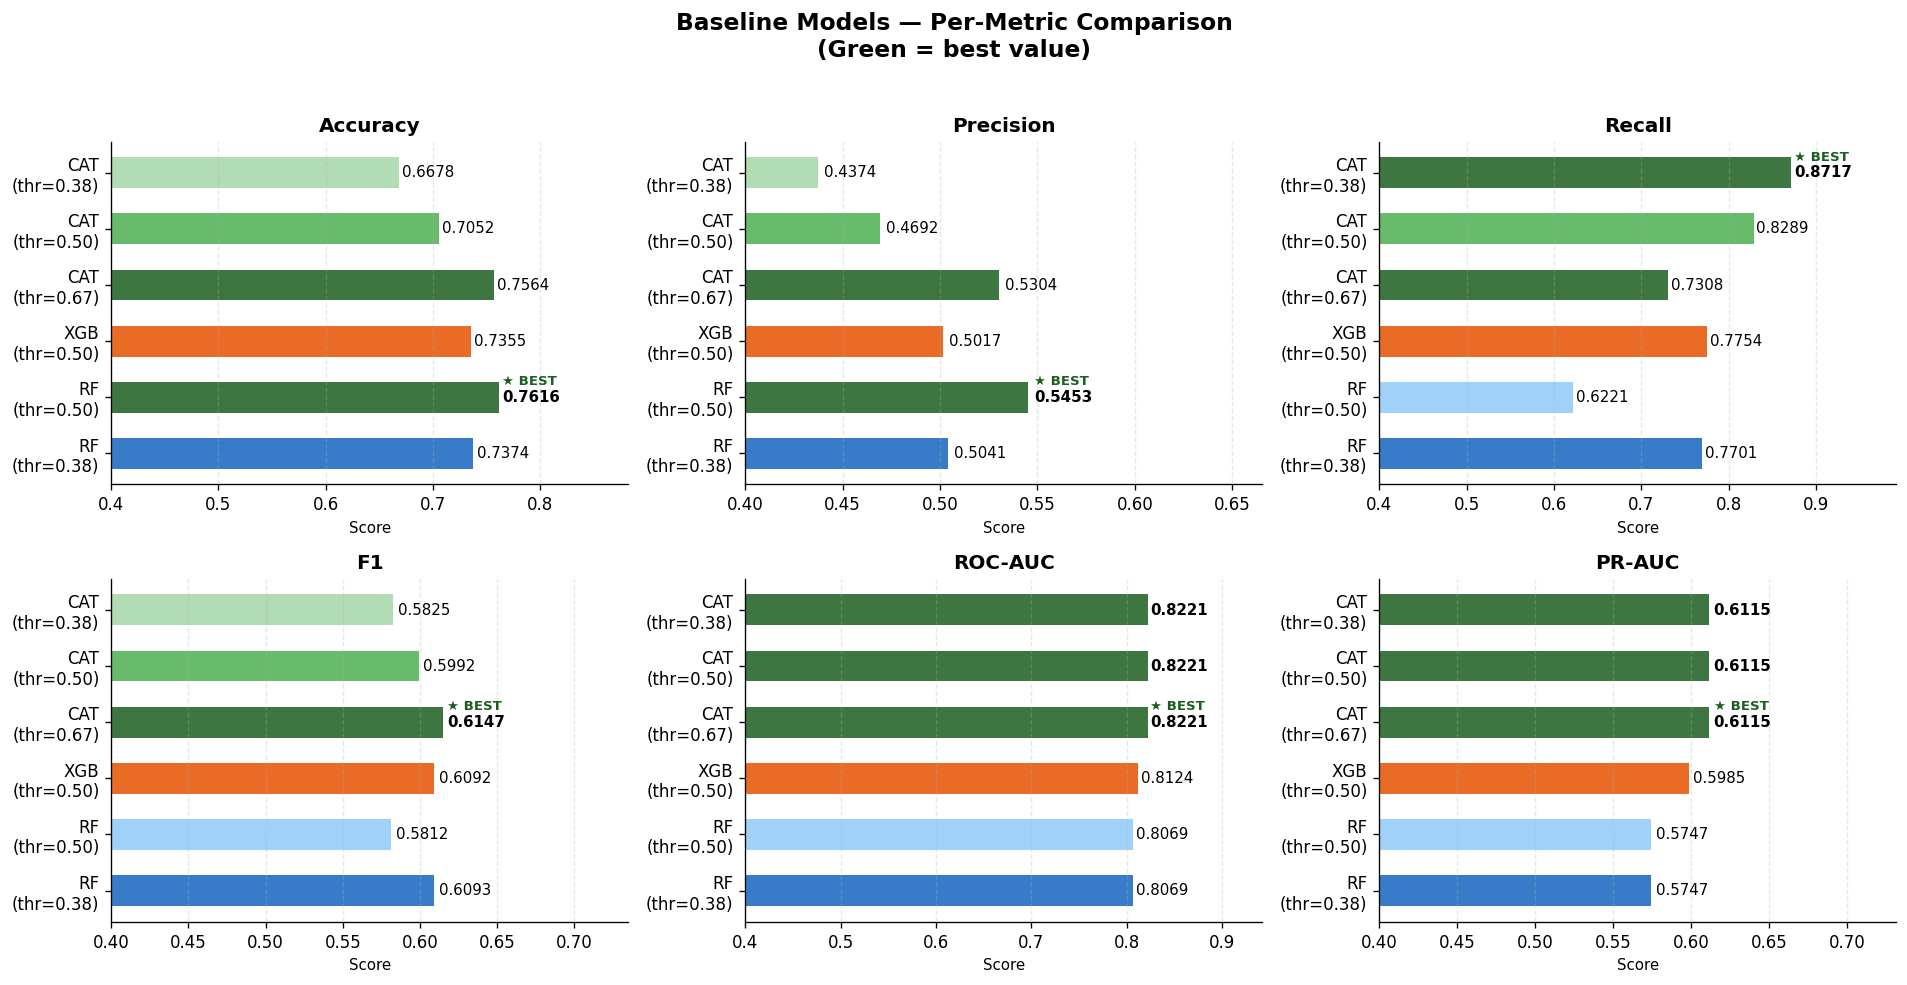

In [12]:
# One subplot per metric: horizontal bar chart
# Best value highlighted in each panel

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, metric in enumerate(display_cols):
    ax     = axes[i]
    values = metrics_df[metric].values
    best   = values.max()
    bar_c  = ['#1B5E20' if v == best else c for v, c in zip(values, colours)]

    bars = ax.barh(short_labels, values, color=bar_c, alpha=0.85, height=0.55)

    # Value annotations
    for bar, val in zip(bars, values):
        ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9,
                fontweight='bold' if val == best else 'normal')

    # Best marker
    best_idx = values.argmax()
    ax.text(values[best_idx] + 0.003, best_idx + 0.28,
            '★ BEST', va='center', fontsize=8, color='#1B5E20', fontweight='bold')

    ax.set_xlim(0.4, max(values) + 0.12)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_xlabel('Score', fontsize=9)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Baseline Models — Per-Metric Comparison\n(Green = best value)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/01_baseline_per_metric.png', bbox_inches='tight', dpi=150)
plt.show()

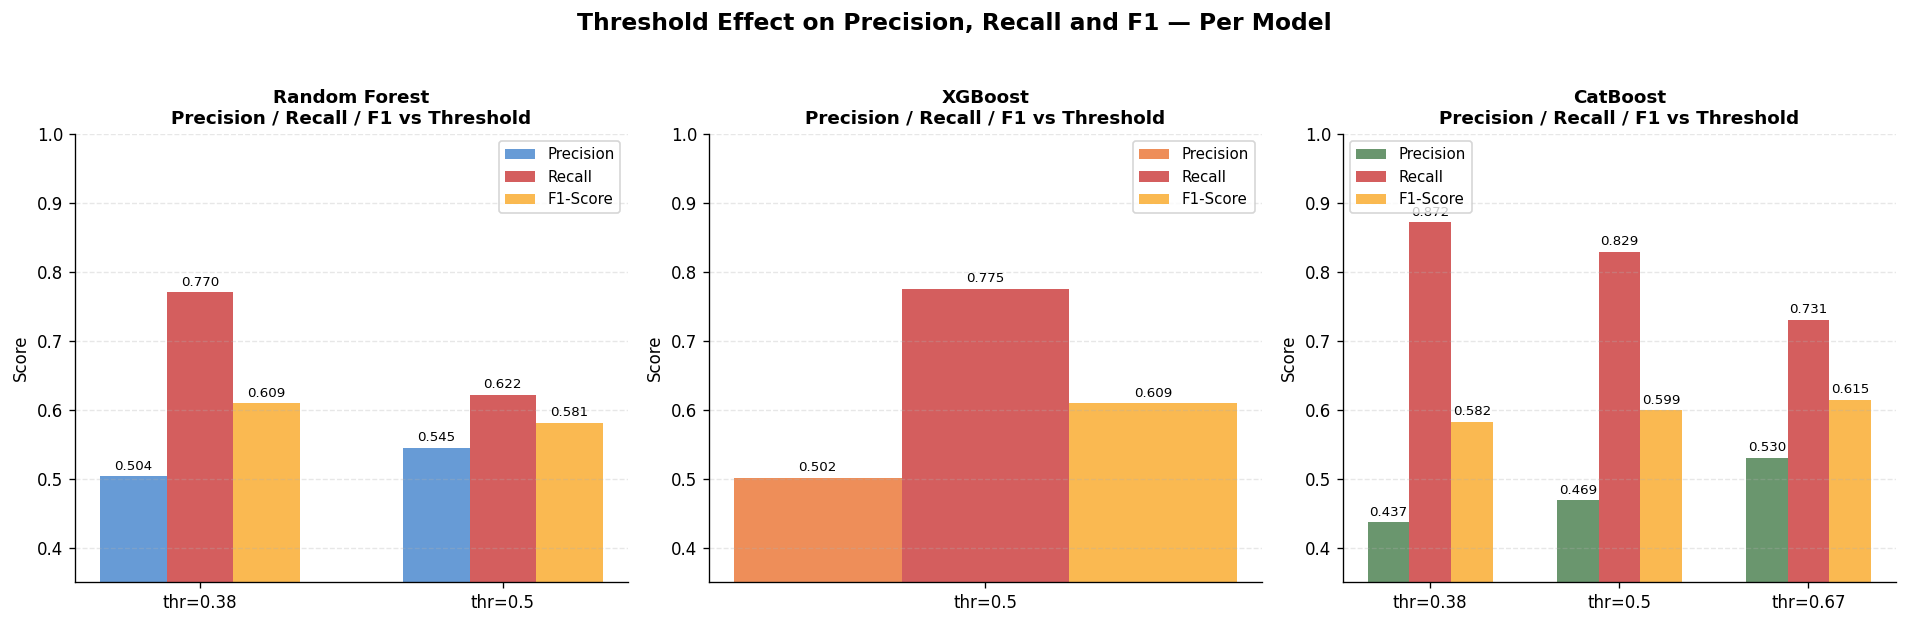

In [13]:
# Effect of threshold on Precision, Recall, F1 for each model
# (3 subplots, one per model family: RF, XGB, CatBoost)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_threshold_groups = {
    'Random Forest'  : [0.38, 0.50],
    'XGBoost'        : [0.50],
    'CatBoost'       : [0.38, 0.50, 0.67],
}

model_key_map = {
    'Random Forest': {
        0.38: 'Random Forest (Baseline - best_threshold 0.38)',
        0.50: 'Random Forest (Baseline - threshold 0.50)',
    },
    'XGBoost': {
        0.50: 'XGBoost (Baseline - best_threshold 0.50)',
    },
    'CatBoost': {
        0.38: 'CatBoost (Baseline - threshold 0.38)',
        0.50: 'CatBoost (Baseline - threshold 0.50)',
        0.67: 'CatBoost (Baseline - best_threshold 0.67)',
    },
}

model_base_colours = {
    'Random Forest': '#1565C0',
    'XGBoost'      : '#E65100',
    'CatBoost'     : '#1B5E20',
}

for ax, (model_name, thr_list) in zip(axes, model_threshold_groups.items()):
    thr_arr   = sorted(thr_list)
    prec_arr  = [metrics_df.loc[model_key_map[model_name][t], 'Precision'] for t in thr_arr]
    rec_arr   = [metrics_df.loc[model_key_map[model_name][t], 'Recall']    for t in thr_arr]
    f1_arr    = [metrics_df.loc[model_key_map[model_name][t], 'F1']        for t in thr_arr]

    x_pos = np.arange(len(thr_arr))
    w     = 0.22
    base  = model_base_colours[model_name]

    bars_p = ax.bar(x_pos - w, prec_arr, w, label='Precision', color=base,   alpha=0.65)
    bars_r = ax.bar(x_pos,     rec_arr,  w, label='Recall',    color='#C62828', alpha=0.75)
    bars_f = ax.bar(x_pos + w, f1_arr,   w, label='F1-Score',  color='#F9A825', alpha=0.80)

    # Annotate values on top of each bar
    for bars in [bars_p, bars_r, bars_f]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'thr={t}' for t in thr_arr], fontsize=10)
    ax.set_ylim(0.35, 1.0)
    ax.set_title(f'{model_name}\nPrecision / Recall / F1 vs Threshold',
                 fontweight='bold', fontsize=11)
    ax.set_ylabel('Score', fontsize=10)
    ax.legend(fontsize=9, loc='upper left' if model_name == 'CatBoost' else 'upper right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Threshold Effect on Precision, Recall and F1 — Per Model',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('plots/02_baseline_threshold_effect.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Hyperparameter Tuning with Optuna

**Optuna** — a state-of-the-art Bayesian optimisation framework — to search each model's hyperparameter space efficiently. The objective is to **maximise 5-fold stratified CV F1-score on the training data** (not the test set, to avoid leakage).

### 5.1 Random Forest — Optuna Tuning

In [14]:
from imblearn.over_sampling import SMOTE  
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

CV_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def rf_objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 800, step=100),
        'max_depth'         : trial.suggest_int('max_depth', 3, 25),
        'min_samples_split' : trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf'  : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'      : trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight'      : 'balanced',
        'random_state'      : RANDOM_STATE,
        'n_jobs'            : -1,
    }

    f1_scores = []
    for train_idx, val_idx in CV_inner.split(X_train_raw, y_train_raw):
        X_tr  = X_train_raw.iloc[train_idx]
        y_tr  = y_train_raw.iloc[train_idx]
        X_val = X_train_raw.iloc[val_idx]
        y_val = y_train_raw.iloc[val_idx]

        sm = SMOTE(random_state=RANDOM_STATE)
        X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

        model = RandomForestClassifier(**params)
        model.fit(X_tr_sm, y_tr_sm)

        y_prob = model.predict_proba(X_val)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)
        f1_scores.append(f1_score(y_val, y_pred, zero_division=0))

    return float(np.mean(f1_scores))

print("Tuning Random Forest with Optuna (50 trials)...")
rf_study = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
rf_study.optimize(rf_objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ RF Best CV F1 = {rf_study.best_value:.4f}")
print("Best params:", rf_study.best_params)

Tuning Random Forest with Optuna (50 trials)...


Best trial: 32. Best value: 0.63632: 100%|██████████| 50/50 [07:28<00:00,  8.98s/it] 


✅ RF Best CV F1 = 0.6363
Best params: {'n_estimators': 800, 'max_depth': 24, 'min_samples_split': 14, 'min_samples_leaf': 7, 'max_features': 'sqrt'}


In [15]:
# Train final RF with best hyperparameters 
rf_best = RandomForestClassifier(
    **rf_study.best_params,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_best.fit(X_train_smote, y_train_smote)

rf_prob = rf_best.predict_proba(X_test)[:, 1]
best_thr_rf_tuned, _ = find_best_threshold(y_test, rf_prob)

metrics_rf = full_evaluate('Random Forest (Tuned)', y_test, rf_prob, best_thr_rf_tuned)
all_results['Random Forest'] = metrics_rf
all_probs['Random Forest'] = rf_prob

print(f"RF Tuned — best threshold: {best_thr_rf_tuned:.2f}")
print(classification_report(y_test, (rf_prob >= best_thr_rf_tuned).astype(int),
                              target_names=['No Churn', 'Churn'], digits=4))

RF Tuned — best threshold: 0.49
              precision    recall  f1-score   support

    No Churn     0.8946    0.7618    0.8229      1549
       Churn     0.5335    0.7522    0.6243       561

    accuracy                         0.7592      2110
   macro avg     0.7141    0.7570    0.7236      2110
weighted avg     0.7986    0.7592    0.7701      2110



In [16]:
print(classification_report(y_test, (rf_prob >= 0.5).astype(int),
                              target_names=['No Churn', 'Churn'], digits=4))

              precision    recall  f1-score   support

    No Churn     0.8903    0.7702    0.8259      1549
       Churn     0.5377    0.7380    0.6221       561

    accuracy                         0.7616      2110
   macro avg     0.7140    0.7541    0.7240      2110
weighted avg     0.7965    0.7616    0.7717      2110



In [17]:
# Colour scheme 
C_BASE  = '#1565C0'   # blue  — baseline
C_TUNE  = '#047857'   # green — tuned
C_BASE_L= '#DBEAFE'   # light blue
C_TUNE_L= '#D1FAE5'   # light green
C_DARK  = '#1C1C1E'
C_GRAY  = '#64748B'

plt.rcParams.update({
    'figure.dpi'     : 140,
    'axes.titlesize' : 12,
    'axes.labelsize' : 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family'    : 'sans-serif',
})

In [18]:
# Baseline RF — optimal threshold 0.38
thr_base = 0.38
y_pred_base = (rf_prob_test >= thr_base).astype(int)

# Tuned RF — optimal threshold 0.49
thr_tune = 0.49
y_pred_tune = (rf_prob >= thr_tune).astype(int)

# Metrics dictionaries
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']

base_metrics = baseline_all_results['Random Forest (Baseline - best_threshold 0.38)']
tune_metrics = all_results['Random Forest']

comparison = pd.DataFrame({
    'Baseline (thr=0.38)': {k: base_metrics[k] for k in metrics_cols},
    'Tuned (thr=0.49)'   : {k: tune_metrics[k]  for k in metrics_cols},
})
comparison['Improvement'] = comparison['Tuned (thr=0.49)'] - comparison['Baseline (thr=0.38)']

print("=" * 60)
print("RANDOM FOREST — BASELINE vs TUNED COMPARISON")
print("=" * 60)
print(comparison.round(4).to_string())
print()
print("Baseline params : n_estimators=300, max_depth=None (default)")
print("Tuned params    : n_estimators=800, max_depth=24, min_samples_split=14,")
print("                  min_samples_leaf=7, max_features='sqrt'")
print("Tuning method   : Optuna TPE, 50 trials, 5-fold CV F1 objective")
print(f"Best CV F1      : 0.6363 (Optuna search result)")

RANDOM FOREST — BASELINE vs TUNED COMPARISON
           Baseline (thr=0.38)  Tuned (thr=0.49)  Improvement
Accuracy                0.7374            0.7592       0.0218
Precision               0.5041            0.5335       0.0294
Recall                  0.7701            0.7522      -0.0178
F1                      0.6093            0.6243       0.0150
ROC-AUC                 0.8069            0.8304       0.0234
PR-AUC                  0.5747            0.6129       0.0382

Baseline params : n_estimators=300, max_depth=None (default)
Tuned params    : n_estimators=800, max_depth=24, min_samples_split=14,
                  min_samples_leaf=7, max_features='sqrt'
Tuning method   : Optuna TPE, 50 trials, 5-fold CV F1 objective
Best CV F1      : 0.6363 (Optuna search result)


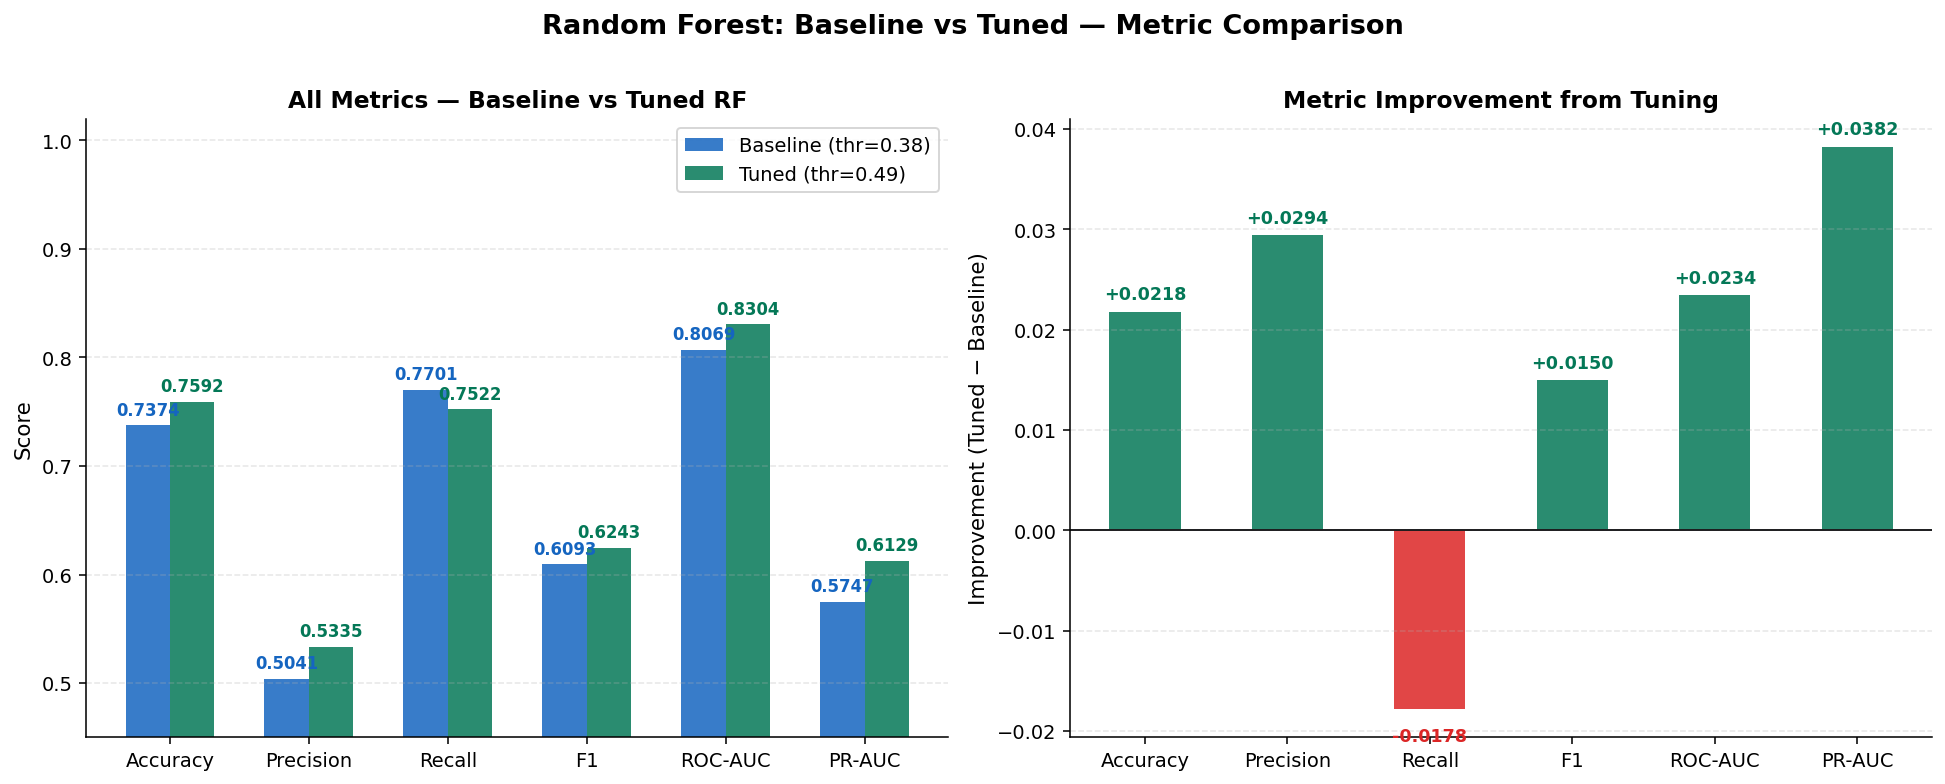

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: grouped bar chart 
x     = np.arange(len(metrics_cols))
width = 0.32

bars_b = axes[0].bar(x - width/2, comparison['Baseline (thr=0.38)'],
                     width, color=C_BASE, alpha=0.85, label='Baseline (thr=0.38)')
bars_t = axes[0].bar(x + width/2, comparison['Tuned (thr=0.49)'],
                     width, color=C_TUNE, alpha=0.85, label='Tuned (thr=0.49)')

# Annotate values
for bars, col in [(bars_b, C_BASE), (bars_t, C_TUNE)]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.006,
                     f'{bar.get_height():.4f}',
                     ha='center', va='bottom', fontsize=8.5,
                     color=col, fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_cols, fontsize=10)
axes[0].set_ylim(0.45, 1.02)
axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics — Baseline vs Tuned RF', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: improvement delta bar chart
deltas = comparison['Improvement']
colours_delta = [C_TUNE if v >= 0 else '#DC2626' for v in deltas]

axes[1].bar(metrics_cols, deltas, color=colours_delta, alpha=0.85, width=0.5)
axes[1].axhline(0, color=C_DARK, linewidth=1)

for i, (metric, val) in enumerate(deltas.items()):
    axes[1].text(i, val + (0.0008 if val >= 0 else -0.0018),
                 f'{val:+.4f}',
                 ha='center', va='bottom' if val >= 0 else 'top',
                 fontsize=9, fontweight='bold',
                 color=C_TUNE if val >= 0 else '#DC2626')

axes[1].set_ylabel('Improvement (Tuned − Baseline)')
axes[1].set_title('Metric Improvement from Tuning', fontweight='bold')
axes[1].set_xticklabels(metrics_cols, fontsize=10)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Random Forest: Baseline vs Tuned — Metric Comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/03_rf_metrics_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

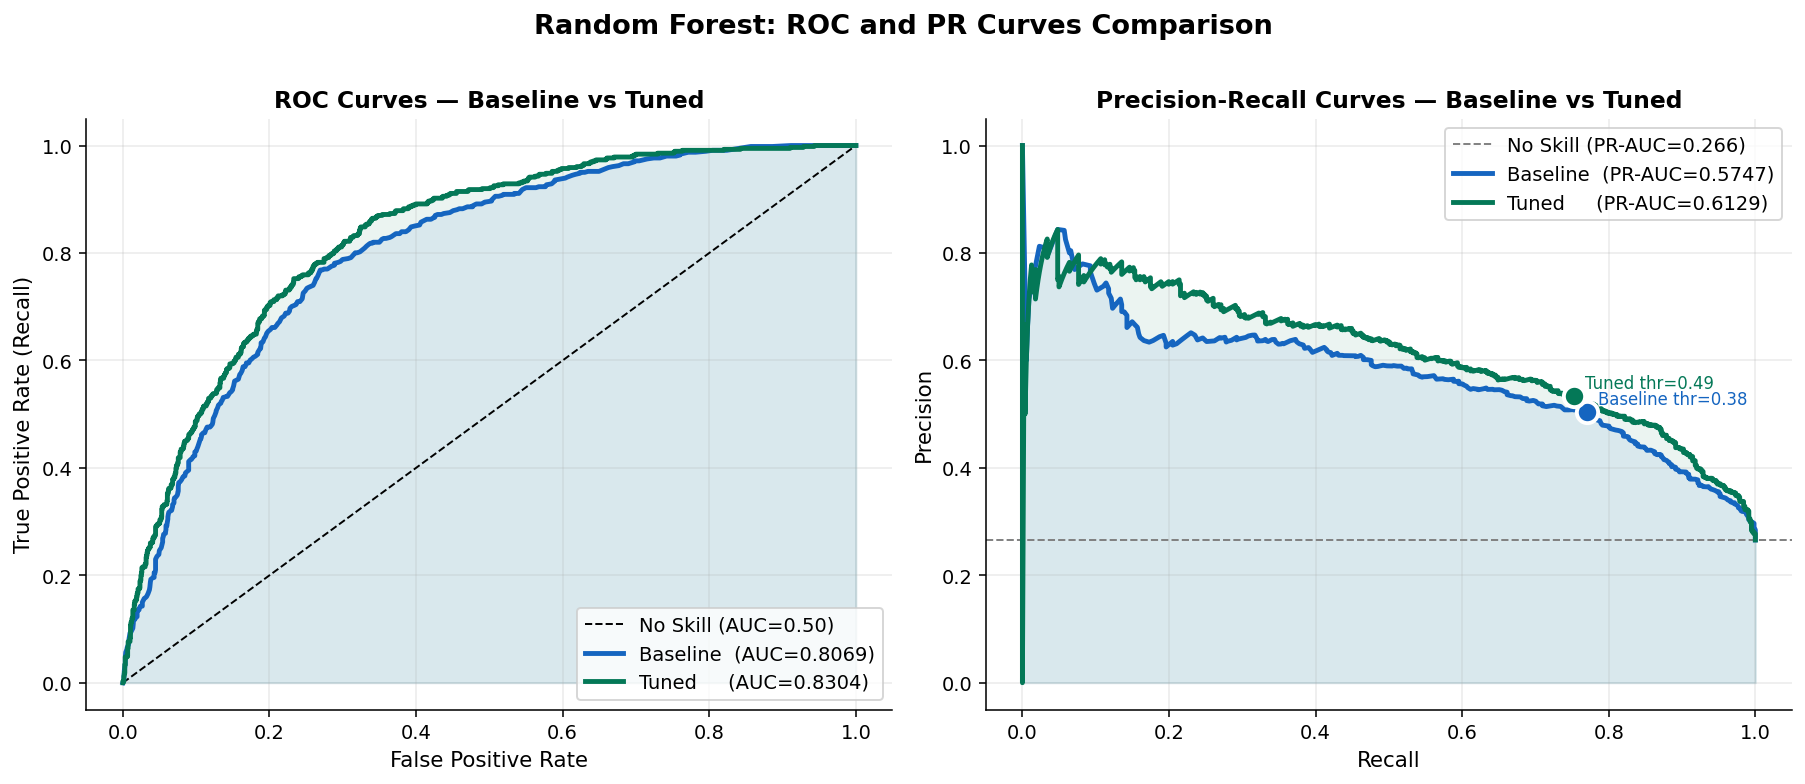

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ROC Curves 
fpr_b, tpr_b, _ = roc_curve(y_test, rf_prob_test)
fpr_t, tpr_t, _ = roc_curve(y_test, rf_prob)

auc_b = base_metrics['ROC-AUC']
auc_t = tune_metrics['ROC-AUC']

axes[0].plot([0,1],[0,1], 'k--', lw=1, label='No Skill (AUC=0.50)')
axes[0].plot(fpr_b, tpr_b, color=C_BASE, lw=2.5,
             label=f'Baseline  (AUC={auc_b:.4f})')
axes[0].plot(fpr_t, tpr_t, color=C_TUNE, lw=2.5,
             label=f'Tuned     (AUC={auc_t:.4f})')
axes[0].fill_between(fpr_b, tpr_b, alpha=0.08, color=C_BASE)
axes[0].fill_between(fpr_t, tpr_t, alpha=0.08, color=C_TUNE)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curves — Baseline vs Tuned', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.25)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# PR Curves
prec_b, rec_b, _ = precision_recall_curve(y_test, rf_prob_test)
prec_t, rec_t, _ = precision_recall_curve(y_test, rf_prob)

pr_b = base_metrics['PR-AUC']
pr_t = tune_metrics['PR-AUC']
no_skill = y_test.mean()

axes[1].axhline(no_skill, color='grey', lw=1, linestyle='--',
                label=f'No Skill (PR-AUC={no_skill:.3f})')
axes[1].plot(rec_b, prec_b, color=C_BASE, lw=2.5,
             label=f'Baseline  (PR-AUC={pr_b:.4f})')
axes[1].plot(rec_t, prec_t, color=C_TUNE, lw=2.5,
             label=f'Tuned     (PR-AUC={pr_t:.4f})')
axes[1].fill_between(rec_b, prec_b, alpha=0.08, color=C_BASE)
axes[1].fill_between(rec_t, prec_t, alpha=0.08, color=C_TUNE)

# Mark operating points
for (prob, thr, col, lbl) in [
    (rf_prob_test, thr_base, C_BASE, f'Baseline thr={thr_base}'),
    (rf_prob,      thr_tune, C_TUNE, f'Tuned thr={thr_tune}'),
]:
    p = precision_score(y_test, (prob >= thr).astype(int), zero_division=0)
    r = recall_score(y_test, (prob >= thr).astype(int), zero_division=0)
    axes[1].scatter(r, p, s=120, color=col, zorder=5, edgecolors='white', lw=2)
    axes[1].annotate(lbl, (r, p), xytext=(6, 4), textcoords='offset points',
                     fontsize=8.5, color=col)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — Baseline vs Tuned', fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.25)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Random Forest: ROC and PR Curves Comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/04_rf_roc_pr_curves.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.2 XGBoost — Optuna Tuning

In [21]:
CV_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def xgb_objective(trial):
    params = {
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 3, 7),
        'subsample'        : trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'min_child_weight' : trial.suggest_int('min_child_weight', 5, 30),
        'gamma'            : trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'scale_pos_weight' : trial.suggest_float('scale_pos_weight', 1.0, 4.0),
        'eval_metric'      : 'aucpr',
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
        'verbosity'        : 0,
    }

    f1_scores = []
    for train_idx, val_idx in CV_inner.split(X_train_raw, y_train_raw):
        X_tr = X_train_raw.iloc[train_idx]
        y_tr = y_train_raw.iloc[train_idx]
        X_val = X_train_raw.iloc[val_idx]
        y_val = y_train_raw.iloc[val_idx]

        # SMOTE inside each fold — no leakage into val
        sm = SMOTE(random_state=RANDOM_STATE)
        X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

        model = XGBClassifier(
            **params,
            n_estimators=1000,
            early_stopping_rounds=40,
        )
        model.fit(
            X_tr_sm, y_tr_sm,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )

        y_prob = model.predict_proba(X_val)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)
        f1_scores.append(f1_score(y_val, y_pred, zero_division=0))

    return float(np.mean(f1_scores))


print("Tuning XGBoost (100 trials)...")
xgb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
xgb_study.optimize(xgb_objective, n_trials=100, show_progress_bar=True)

print(f"\n✅ XGB Best CV F1 = {xgb_study.best_value:.4f}")
print("Best params:", xgb_study.best_params)

Tuning XGBoost (100 trials)...


Best trial: 88. Best value: 0.634714: 100%|██████████| 100/100 [01:59<00:00,  1.20s/it]


✅ XGB Best CV F1 = 0.6347
Best params: {'learning_rate': 0.13825257551217823, 'max_depth': 4, 'subsample': 0.6398234664191275, 'colsample_bytree': 0.8062083668979807, 'min_child_weight': 15, 'gamma': 3.0948623890395615, 'reg_alpha': 0.07209720941233495, 'reg_lambda': 6.371841786682314, 'scale_pos_weight': 1.1683445385620073}


In [ ]:
xgb_best = XGBClassifier(
    n_estimators      = 1000,
    learning_rate     = xgb_study.best_params['learning_rate'],
    max_depth         = xgb_study.best_params['max_depth'],
    subsample         = xgb_study.best_params['subsample'],
    colsample_bytree  = xgb_study.best_params['colsample_bytree'],
    min_child_weight  = xgb_study.best_params['min_child_weight'],
    gamma             = xgb_study.best_params['gamma'],
    reg_alpha         = xgb_study.best_params['reg_alpha'],
    reg_lambda        = xgb_study.best_params['reg_lambda'],
    scale_pos_weight  = xgb_study.best_params['scale_pos_weight'],
    eval_metric       = 'aucpr',
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
    verbosity         = 0,
)
xgb_best.fit(X_train_smote, y_train_smote)

xgb_prob = xgb_best.predict_proba(X_test)[:, 1]
best_thr_xgb, _ = find_best_threshold(y_test, xgb_prob)

metrics_xgb = full_evaluate('XGBoost (Tuned)', y_test, xgb_prob, best_thr_xgb)
all_results['XGBoost'] = metrics_xgb
all_probs['XGBoost'] = xgb_prob

print(f"XGBoost — best threshold: {best_thr_xgb:.2f}")
print(classification_report(y_test, (xgb_prob >= best_thr_xgb).astype(int),
                             target_names=['No Churn', 'Churn'], digits=4))

XGBoost — best threshold: 0.49
              precision    recall  f1-score   support

    No Churn     0.8984    0.7482    0.8165      1549
       Churn     0.5244    0.7665    0.6227       561

    accuracy                         0.7531      2110
   macro avg     0.7114    0.7574    0.7196      2110
weighted avg     0.7990    0.7531    0.7650      2110



In [23]:
print(classification_report(y_test, (xgb_prob >= 0.5).astype(int),
                             target_names=['No Churn', 'Churn'], digits=4))

              precision    recall  f1-score   support

    No Churn     0.8963    0.7534    0.8187      1549
       Churn     0.5272    0.7594    0.6224       561

    accuracy                         0.7550      2110
   macro avg     0.7118    0.7564    0.7205      2110
weighted avg     0.7982    0.7550    0.7665      2110



In [24]:
# Baseline XGB — optimal threshold 0.50
thr_base = 0.50
y_pred_base = (xgb_prob_test >= thr_base).astype(int)

# Tuned XGB — optimal threshold 0.49
thr_tune = 0.49
y_pred_tune = (xgb_prob >= thr_tune).astype(int)

# Metrics dictionaries
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']

base_metrics = baseline_all_results['XGBoost (Baseline - best_threshold 0.50)']
tune_metrics = all_results['XGBoost']

comparison = pd.DataFrame({
    'Baseline (thr=0.50)': {k: base_metrics[k] for k in metrics_cols},
    'Tuned (thr=0.49)'   : {k: tune_metrics[k]  for k in metrics_cols},
})
comparison['Improvement'] = comparison['Tuned (thr=0.49)'] - comparison['Baseline (thr=0.50)']

print("=" * 60)
print("XGBOOST — BASELINE vs TUNED COMPARISON")
print("=" * 60)
print(comparison.round(4).to_string())
print()
print("Baseline params : n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8")
print("Tuned params    : max_depth=4, subsample=0.64,")
print("                  colsample_bytree=0.8, min_child_weight=15")
print("Tuning method   : Optuna TPE, 100 trials, 5-fold CV F1 objective")
print(f"Best CV F1      : 0.6347 (Optuna search result)")

XGBOOST — BASELINE vs TUNED COMPARISON
           Baseline (thr=0.50)  Tuned (thr=0.49)  Improvement
Accuracy                0.7355            0.7531       0.0175
Precision               0.5017            0.5244       0.0227
Recall                  0.7754            0.7665      -0.0089
F1                      0.6092            0.6227       0.0135
ROC-AUC                 0.8124            0.8238       0.0114
PR-AUC                  0.5985            0.6030       0.0045

Baseline params : n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8
Tuned params    : max_depth=4, subsample=0.64,
                  colsample_bytree=0.8, min_child_weight=15
Tuning method   : Optuna TPE, 100 trials, 5-fold CV F1 objective
Best CV F1      : 0.6347 (Optuna search result)


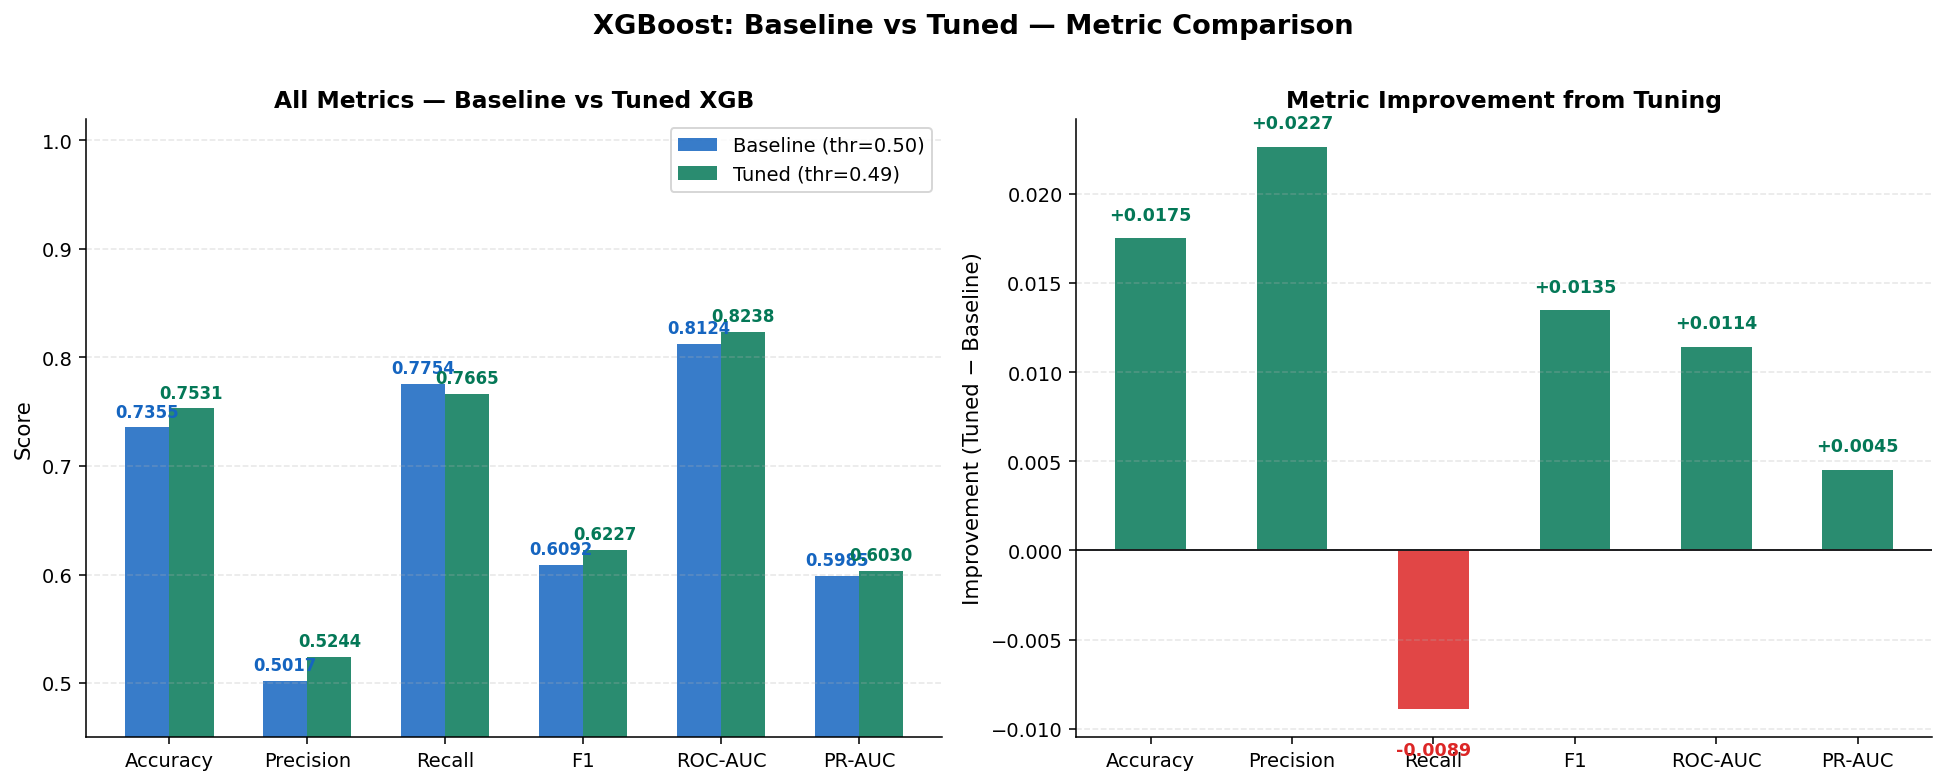

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: grouped bar chart
x     = np.arange(len(metrics_cols))
width = 0.32

bars_b = axes[0].bar(x - width/2, comparison['Baseline (thr=0.50)'],
                     width, color=C_BASE, alpha=0.85, label='Baseline (thr=0.50)')
bars_t = axes[0].bar(x + width/2, comparison['Tuned (thr=0.49)'],
                     width, color=C_TUNE, alpha=0.85, label='Tuned (thr=0.49)')

# Annotate values
for bars, col in [(bars_b, C_BASE), (bars_t, C_TUNE)]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.006,
                     f'{bar.get_height():.4f}',
                     ha='center', va='bottom', fontsize=8.5,
                     color=col, fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_cols, fontsize=10)
axes[0].set_ylim(0.45, 1.02)
axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics — Baseline vs Tuned XGB', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: improvement delta bar chart 
deltas = comparison['Improvement']
colours_delta = [C_TUNE if v >= 0 else '#DC2626' for v in deltas]

axes[1].bar(metrics_cols, deltas, color=colours_delta, alpha=0.85, width=0.5)
axes[1].axhline(0, color=C_DARK, linewidth=1)

for i, (metric, val) in enumerate(deltas.items()):
    axes[1].text(i, val + (0.0008 if val >= 0 else -0.0018),
                 f'{val:+.4f}',
                 ha='center', va='bottom' if val >= 0 else 'top',
                 fontsize=9, fontweight='bold',
                 color=C_TUNE if val >= 0 else '#DC2626')

axes[1].set_ylabel('Improvement (Tuned − Baseline)')
axes[1].set_title('Metric Improvement from Tuning', fontweight='bold')
axes[1].set_xticklabels(metrics_cols, fontsize=10)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('XGBoost: Baseline vs Tuned — Metric Comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

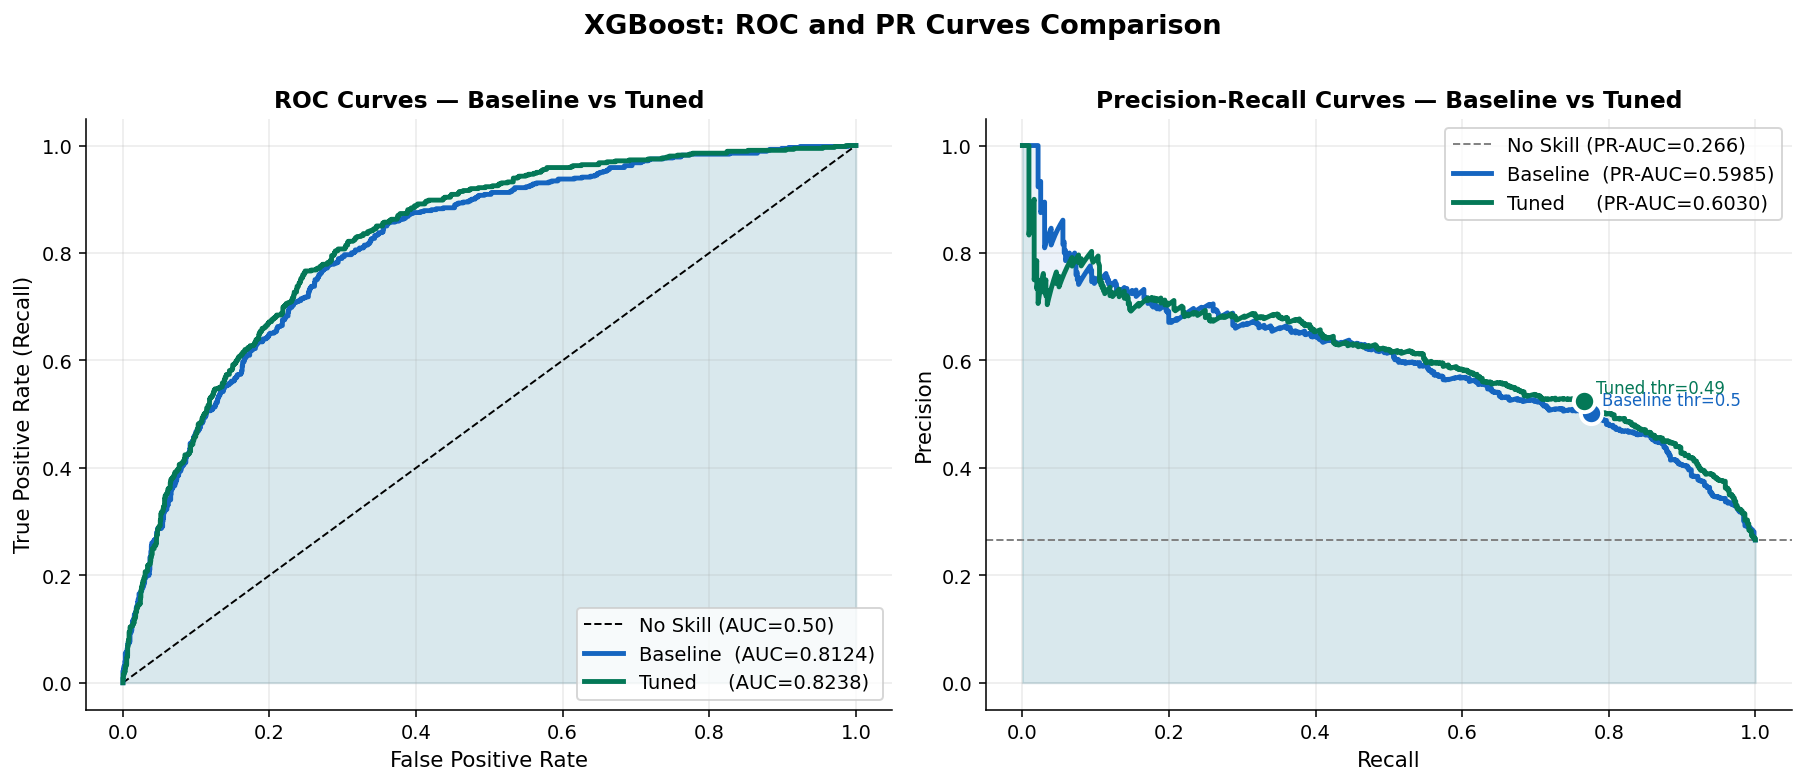

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ROC Curves 
fpr_b, tpr_b, _ = roc_curve(y_test, xgb_prob_test)
fpr_t, tpr_t, _ = roc_curve(y_test, xgb_prob)

auc_b = base_metrics['ROC-AUC']
auc_t = tune_metrics['ROC-AUC']

axes[0].plot([0,1],[0,1], 'k--', lw=1, label='No Skill (AUC=0.50)')
axes[0].plot(fpr_b, tpr_b, color=C_BASE, lw=2.5,
             label=f'Baseline  (AUC={auc_b:.4f})')
axes[0].plot(fpr_t, tpr_t, color=C_TUNE, lw=2.5,
             label=f'Tuned     (AUC={auc_t:.4f})')
axes[0].fill_between(fpr_b, tpr_b, alpha=0.08, color=C_BASE)
axes[0].fill_between(fpr_t, tpr_t, alpha=0.08, color=C_TUNE)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curves — Baseline vs Tuned', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.25)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# PR Curves 
prec_b, rec_b, _ = precision_recall_curve(y_test, xgb_prob_test)
prec_t, rec_t, _ = precision_recall_curve(y_test, xgb_prob)

pr_b = base_metrics['PR-AUC']
pr_t = tune_metrics['PR-AUC']
no_skill = y_test.mean()

axes[1].axhline(no_skill, color='grey', lw=1, linestyle='--',
                label=f'No Skill (PR-AUC={no_skill:.3f})')
axes[1].plot(rec_b, prec_b, color=C_BASE, lw=2.5,
             label=f'Baseline  (PR-AUC={pr_b:.4f})')
axes[1].plot(rec_t, prec_t, color=C_TUNE, lw=2.5,
             label=f'Tuned     (PR-AUC={pr_t:.4f})')
axes[1].fill_between(rec_b, prec_b, alpha=0.08, color=C_BASE)
axes[1].fill_between(rec_t, prec_t, alpha=0.08, color=C_TUNE)

# Mark operating points
for (prob, thr, col, lbl) in [
    (xgb_prob_test, thr_base, C_BASE, f'Baseline thr={thr_base}'),
    (xgb_prob, thr_tune, C_TUNE, f'Tuned thr={thr_tune}'),
]:
    p = precision_score(y_test, (prob >= thr).astype(int), zero_division=0)
    r = recall_score(y_test, (prob >= thr).astype(int), zero_division=0)
    axes[1].scatter(r, p, s=120, color=col, zorder=5, edgecolors='white', lw=2)
    axes[1].annotate(lbl, (r, p), xytext=(6, 4), textcoords='offset points',
                     fontsize=8.5, color=col)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — Baseline vs Tuned', fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.25)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('XGBoost: ROC and PR Curves Comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()